In [1]:
from __future__ import annotations

import os
from pathlib import Path

import h5py
import numpy as np


In [2]:
pip install --upgrade givernylocal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.1/394.1 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.2 MB/s eta 0:00:00
  Attempting uninstall: rpds-py
    Found existing installation: rpds-py 2026.6.3
    Uninstalling rpds-py-2026.6.3:
      Successfully uninstalled rpds-py-2026.6.3
  Attempting uninstall: attrs
    Found existing installation: attrs 26.1.0
    Uninstalling attrs-26.1.0:
      Successfully uninstalled attrs-26.1.0
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0
  Attempting uninstall: jsonschema-specifications


In [3]:
from givernylocal.turbulence_dataset import turb_dataset
from givernylocal.turbulence_toolkit import getCutout

In [4]:
DATASET = "isotropic1024coarse"

OUTPUT_DIR = Path("data/jhtdb_raw")
OUTPUT_FILE = Path("data/jhtdb_planes.h5")

In [5]:
os.environ["JHTDB_TOKEN"] = "edu.jhu.pha.turbulence.testing-201406"
TOKEN = os.environ["JHTDB_TOKEN"]

In [12]:
TOKEN = os.environ.get("JHTDB_TOKEN", "")
DATASET = "isotropic1024coarse"
# ======================
# Paramètres
# ======================

TOKEN = "edu.jhu.pha.turbulence.testing-201406"

DATASET = "isotropic1024coarse"

X_RANGE = [1, 64]
Y_RANGE = [1, 64]

Z_INDICES = [64, 256, 512]

T_START = 1
T_END = 100

OUTPUT_DIR = Path("data/jhtdb_test/raw")
OUTPUT_H5 = Path("data/jhtdb_test/small_planes.h5")


# ======================
# Initialisation JHTDB
# ======================

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_H5.parent.mkdir(parents=True, exist_ok=True)

cube = turb_dataset(
    dataset_title=DATASET,
    output_path=str(OUTPUT_DIR),
    auth_token=TOKEN,
)


# ======================
# Allocation du tableau final
# ======================

time_indices = list(range(T_START, T_END + 1))

S = len(Z_INDICES)
T = len(time_indices)
H = Y_RANGE[1] - Y_RANGE[0] + 1
W = X_RANGE[1] - X_RANGE[0] + 1

all_u = np.zeros((S, T, H, W, 3), dtype=np.float32)


# ======================
# Requêtes JHTDB
# ======================

strides = np.array([1, 1, 1, 1], dtype=np.int64)

for s, z in enumerate(Z_INDICES):
    for ti, t in enumerate(time_indices):
        print(f"Query z={z}, t={t}")

        ranges = np.array(
            [
                X_RANGE,
                Y_RANGE,
                [z, z],
                [t, t],
            ],
            dtype=np.int64,
        )

        ds = getCutout(
            cube,
            "velocity",
            ranges,
            strides,
            verbose=False,
        )

        # On récupère directement la première variable du Dataset xarray
        da = list(ds.data_vars.values())[0]
        arr = np.asarray(da.values, dtype=np.float32)

        # arr.shape attendu : (1, H, W, 3)
        all_u[s, ti] = arr[0, :, :, :]


# ======================
# Sauvegarde HDF5
# ======================

with h5py.File(OUTPUT_H5, "w") as f:
    f.create_dataset("u", data=all_u[..., 0], compression="lzf")
    f.create_dataset("v", data=all_u[..., 1], compression="lzf")
    f.create_dataset("w", data=all_u[..., 2], compression="lzf")
    f.create_dataset("z_indices", data=np.asarray(Z_INDICES))
    f.create_dataset("time_indices", data=np.asarray(time_indices))

    f.attrs["dataset"] = DATASET
    f.attrs["x_range"] = X_RANGE
    f.attrs["y_range"] = Y_RANGE

print("Saved:", OUTPUT_H5)
print("u shape:", all_u.shape)

Query z=64, t=1
Query z=64, t=2
Query z=64, t=3
Query z=64, t=4
Query z=64, t=5
Query z=64, t=6
Query z=64, t=7
Query z=64, t=8
Query z=64, t=9
Query z=64, t=10
Query z=64, t=11
Query z=64, t=12
Query z=64, t=13
Query z=64, t=14
Query z=64, t=15
Query z=64, t=16
Query z=64, t=17
Query z=64, t=18
Query z=64, t=19
Query z=64, t=20
Query z=64, t=21
Query z=64, t=22
Query z=64, t=23
Query z=64, t=24
Query z=64, t=25
Query z=64, t=26
Query z=64, t=27
Query z=64, t=28
Query z=64, t=29
Query z=64, t=30
Query z=64, t=31
Query z=64, t=32
Query z=64, t=33
Query z=64, t=34
Query z=64, t=35
Query z=64, t=36
Query z=64, t=37
Query z=64, t=38
Query z=64, t=39
Query z=64, t=40
Query z=64, t=41
Query z=64, t=42
Query z=64, t=43
Query z=64, t=44
Query z=64, t=45
Query z=64, t=46
Query z=64, t=47
Query z=64, t=48
Query z=64, t=49
Query z=64, t=50
Query z=64, t=51
Query z=64, t=52
Query z=64, t=53
Query z=64, t=54
Query z=64, t=55
Query z=64, t=56
Query z=64, t=57
Query z=64, t=58
Query z=64, t=59
Query 

u shape: (3, 100, 64, 64)
z_indices: [ 64 256 512]
time_indices: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100]
sample_indices: [ 0 16 33 49 66 82 99]
sampled time_indices: [  1  17  34  50  67  83 100]


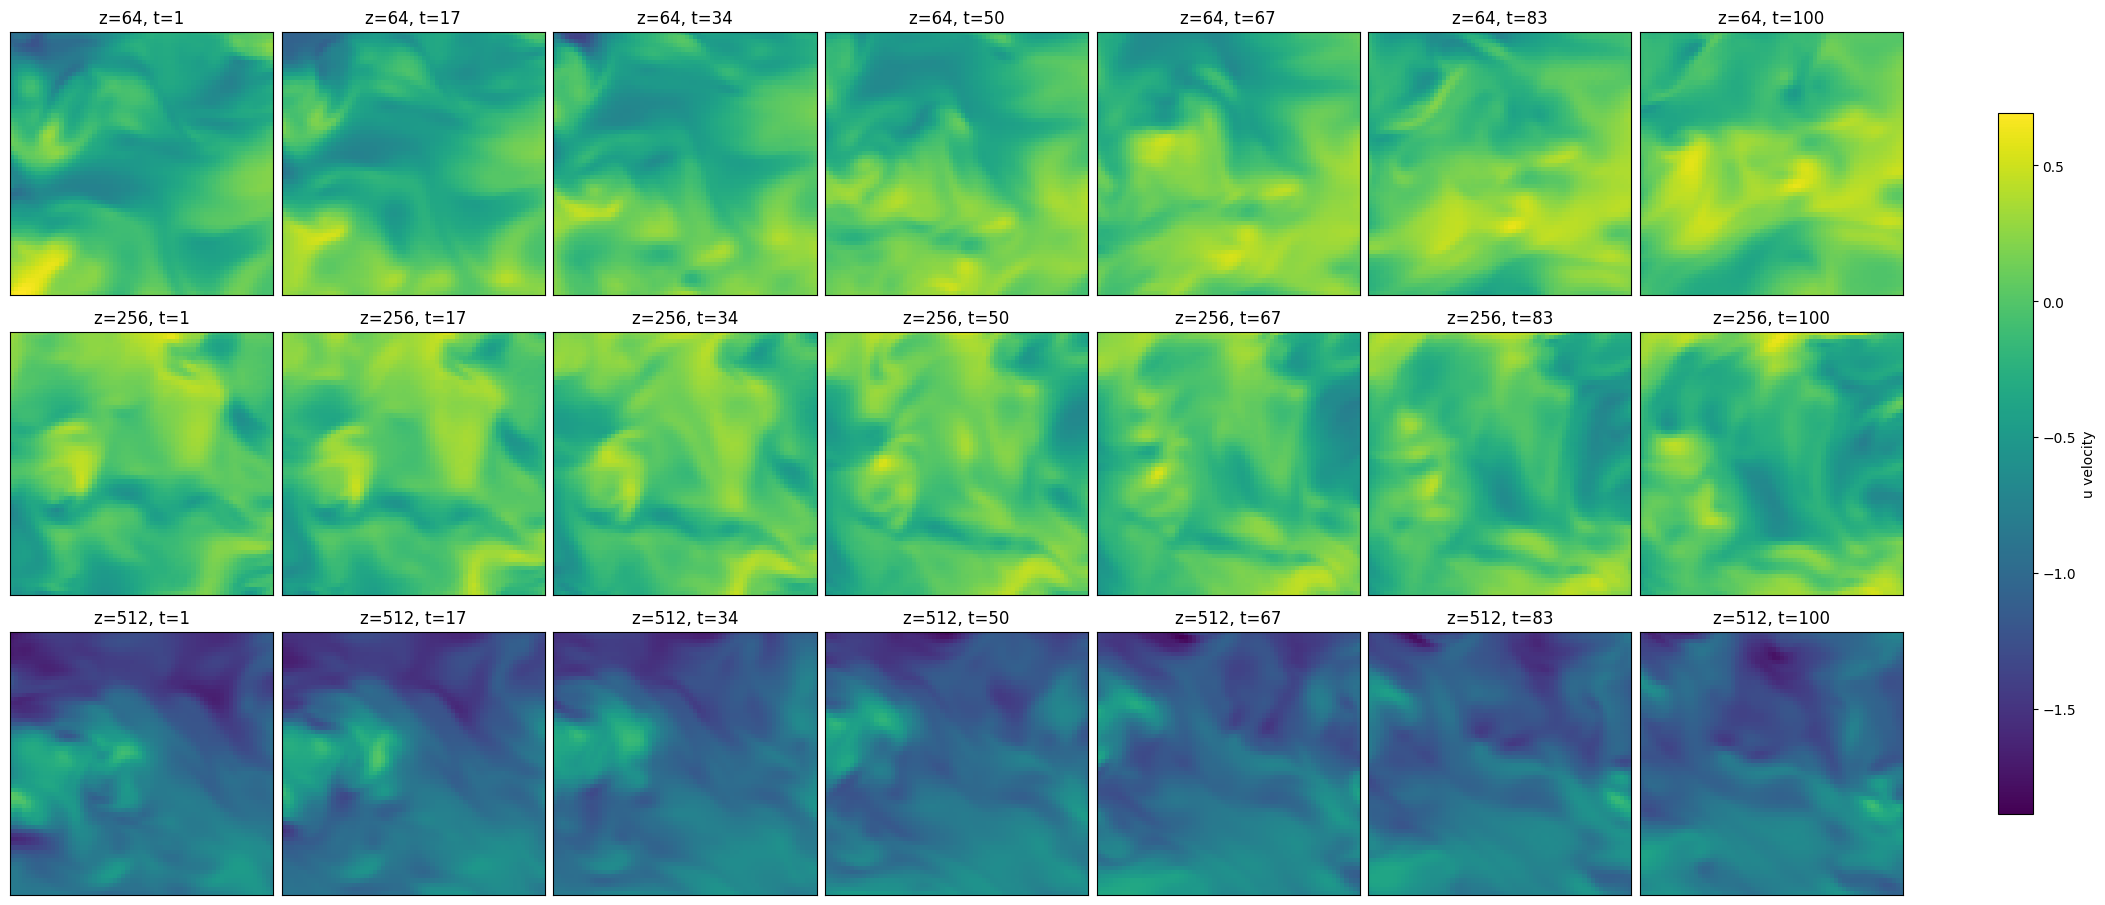

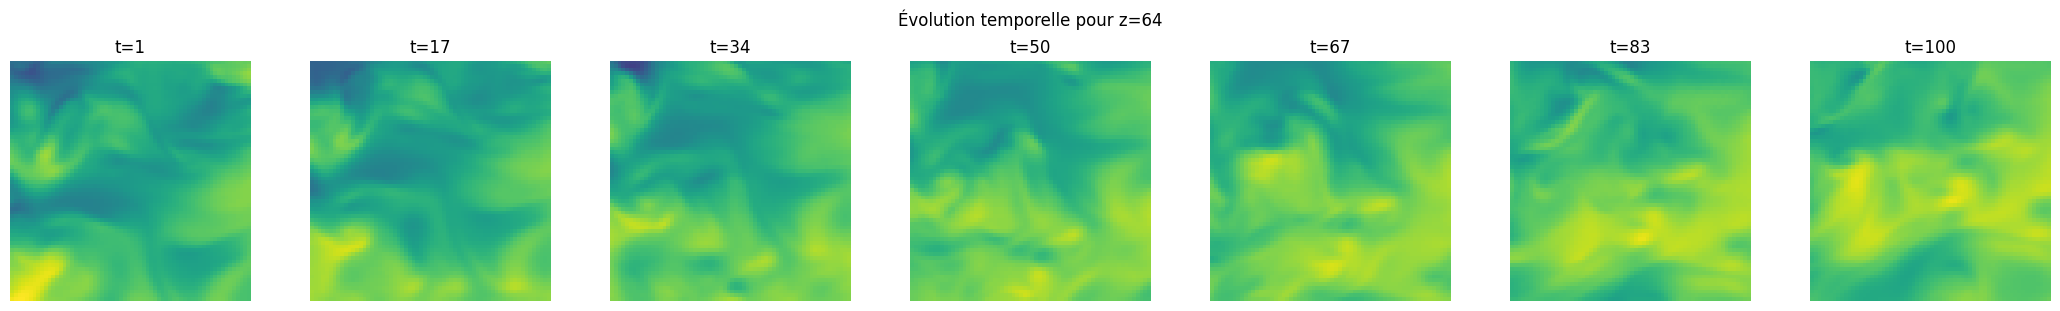

In [15]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Chemin du fichier sauvegardé
h5_path = "data/jhtdb_test/small_planes.h5"

# Chargement
with h5py.File(h5_path, "r") as f:
    u = f["u"][:]                      # shape (S, T, H, W)
    z_indices = f["z_indices"][:]
    time_indices = f["time_indices"][:]

print("u shape:", u.shape)
print("z_indices:", z_indices)
print("time_indices:", time_indices)

S, nT, H, W = u.shape

# Nombre de frames à afficher
n_samples = 7

# Indices temporels régulièrement espacés entre 0 et nT-1
sample_indices = np.linspace(0, nT - 1, min(n_samples, nT), dtype=int)

print("sample_indices:", sample_indices)
print("sampled time_indices:", time_indices[sample_indices])

# Échelle de couleur commune
vmin = u.min()
vmax = u.max()

# =====================================================
# Visualisation globale : lignes = coupes z, colonnes = temps
# =====================================================

fig, axes = plt.subplots(
    S,
    len(sample_indices),
    figsize=(3 * len(sample_indices), 3 * S),
    constrained_layout=True,
    squeeze=False,
)

for s in range(S):
    for j, t_idx in enumerate(sample_indices):
        ax = axes[s, j]

        im = ax.imshow(
            u[s, t_idx],
            origin="upper",
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
        )

        ax.set_title(f"z={z_indices[s]}, t={time_indices[t_idx]}")
        ax.set_xticks([])
        ax.set_yticks([])

fig.colorbar(im, ax=axes, shrink=0.8, label="u velocity")
plt.show()


# =====================================================
# Évolution temporelle pour une seule coupe
# =====================================================

slice_id = 0  # 0 -> première coupe, 1 -> deuxième, etc.

fig, axes = plt.subplots(
    1,
    len(sample_indices),
    figsize=(3 * len(sample_indices), 3),
    constrained_layout=True,
    squeeze=False,
)

for j, t_idx in enumerate(sample_indices):
    ax = axes[0, j]

    ax.imshow(
        u[slice_id, t_idx],
        origin="upper",
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(f"t={time_indices[t_idx]}")
    ax.axis("off")

fig.suptitle(f"Évolution temporelle pour z={z_indices[slice_id]}")
plt.show()